# Credit Card Fraud Detection

Dataset: Kaggle "Credit Card Fraud Detection" by Dhanush Narayanan R
Records: about 1,000,000 transactions, target column `fraud` (8.74% positive)

Five classifiers are compared under three sampling methods. The stratified train/test split is done before any resampling, so the test set keeps the real ~8% fraud rate and is never resampled.

In [1]:
%matplotlib inline

import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC  # much faster than SVC on 1M rows
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# imbalanced-learn for under/oversampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# hide convergence warnings to keep the output readable
warnings.filterwarnings('ignore')

# notebooks don't have __file__, so use the current directory
NOTEBOOK_DIR = os.getcwd()

# all charts go in a charts/ folder
CHART_DIR = os.path.join(NOTEBOOK_DIR, 'charts')
os.makedirs(CHART_DIR, exist_ok=True)

## Step 1: Import Dataset

Load the CSV and check the target column and shape.

In [2]:
# Step 1: load the data

csv_path = os.path.join(NOTEBOOK_DIR, 'card_transdata.csv')
df = pd.read_csv(csv_path)

print(f"File loaded   : {os.path.basename(csv_path)}")
print(f"Shape         : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns       : {list(df.columns)}")
print(f"Target column : 'fraud'")
print(f"Fraud count   : {int(df['fraud'].sum()):,}  ({df['fraud'].mean()*100:.2f}%  of total)")

File loaded   : card_transdata.csv
Shape         : 1,000,000 rows x 8 columns
Columns       : ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']
Target column : 'fraud'
Fraud count   : 87,403  (8.74%  of total)


## Step 2: Identify Data Quality Issues

This step only checks the data and doesn't change anything. It looks at column types, missing values, duplicate rows and class balance.

In [3]:
# Step 2: check data quality (nothing is changed here)

print('--- Column types ---')
print(df.dtypes.to_string())

print('\n--- Missing values per column ---')
missing = df.isnull().sum()
print(missing.to_string())
print(f"  Total missing cells: {missing.sum()}")

print('\n--- Duplicate rows ---')
n_dupes = df.duplicated().sum()
print(f"  Duplicate rows found: {n_dupes:,}")

print('\n--- Class balance ---')
for label in sorted(df['fraud'].unique()):
    count = (df['fraud'] == label).sum()
    name  = 'Fraud' if label == 1 else 'Non-Fraud'
    print(f"  Class {int(label)} ({name:<10}) : {count:>10,}  ({count/len(df)*100:.2f}%)")

--- Column types ---
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64

--- Missing values per column ---
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
  Total missing cells: 0

--- Duplicate rows ---


  Duplicate rows found: 0

--- Class balance ---
  Class 0 (Non-Fraud ) :    912,597  (91.26%)
  Class 1 (Fraud     ) :     87,403  (8.74%)


## Step 3: Handle Data Quality Issues

- Drop duplicate rows and rows with missing values (there aren't any, but this keeps it safe if the data changes).
- Scale the 3 continuous features with `StandardScaler` so features with large values don't dominate LR and SVM.
- Leave the 4 binary features (0/1) as they are, since scaling them doesn't help.

Note: `StandardScaler` is fitted on the full dataset here, which is a small leak. Resampling is only applied to the training data inside the experiment loop.

In [4]:
# Step 3: clean the data and scale the continuous features

# drop duplicates and missing values
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Rows after deduplication : {len(df_clean):,}")

df_clean = df_clean.dropna().reset_index(drop=True)
print(f"Rows after dropna        : {len(df_clean):,}")

# only the continuous features need scaling
CONTINUOUS_FEATURES = [
    'distance_from_home',
    'distance_from_last_transaction',
    'ratio_to_median_purchase_price',
]
BINARY_FEATURES = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
TARGET_COL      = 'fraud'

# note: scaler is fit on the full dataset
scaler = StandardScaler()
df_clean[CONTINUOUS_FEATURES] = scaler.fit_transform(df_clean[CONTINUOUS_FEATURES])

print(f"\nContinuous features scaled : {CONTINUOUS_FEATURES}")
print(f"Binary features unchanged  : {BINARY_FEATURES}")

# numpy arrays are faster to index in the loop
X = df_clean.drop(columns=[TARGET_COL]).values
y = df_clean[TARGET_COL].values.astype(int)

print(f"\nFeature matrix X : {X.shape}")
print(f"Label vector   y : {y.shape}")
print(f"Fraud rate       : {y.mean()*100:.2f}%")

Rows after deduplication : 1,000,000
Rows after dropna        : 1,000,000

Continuous features scaled : ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']
Binary features unchanged  : ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

Feature matrix X : (1000000, 7)
Label vector   y : (1000000,)
Fraud rate       : 8.74%


## Steps 4-8: Experiment Loop

For each of the 10 experiments (each with a different random seed):

1. Do a stratified train/test split. The test set keeps ~8% fraud and isn't changed after this.
2. Apply the sampling method (Normal / Under / Over) to the training data only.
3. Train the 5 models on the training set.
4. Evaluate all models on the same test set.
5. Record accuracy, weighted F1, training time and prediction speed.

Splitting before resampling means no duplicated or removed rows affect the test set, so the scores reflect the real class balance.

In [5]:
N_EXPERIMENTS = 10
TEST_SIZE     = 0.20   # 20% test, 80% train -> 200K / 800K rows
REGIMES       = ['Normal', 'Over', 'Under']

MODEL_NAMES = [
    'Logistic Regression',
    'Naive Bayes',
    'SVM (LinearSVC)',
    'Random Forest',
    'Decision Tree',
]


# returns a fresh set of untrained models
def make_models(seed):
    """
    Instantiate all five models with the given random seed.
    Creating a fresh instance every time avoids carrying over fitted weights
    from a previous experiment.

    Why LinearSVC instead of SVC(kernel='rbf')?
    RBF-SVM scales as O(n^2) or worse; on ~800K rows it would take hours.
    LinearSVC uses a much faster dual-coordinate-descent solver: O(n).
    """
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            solver='liblinear', # Fastest solver for binary LR on large dense data
            random_state=seed,  # liblinear does not support n_jobs; it's still fast
        ),
        'Naive Bayes': GaussianNB(),   # Deterministic given data; no seed needed
        'SVM (LinearSVC)': LinearSVC(
            max_iter=2000,      # Extra iterations prevent premature stopping
            random_state=seed,
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=50,    # 50 trees: good accuracy/speed trade-off at 1M rows
            n_jobs=-1,          # Fit trees in parallel across all CPU cores
            random_state=seed,
        ),
        'Decision Tree': DecisionTreeClassifier(
            random_state=seed,
        ),
    }


# resample the training data only (the test set never goes through this)
def resample_training_data(X_tr, y_tr, regime, seed):
    """
    Return (X_resampled, y_resampled) for the given regime.

    'Normal' -- return X_tr / y_tr unchanged (~8% fraud, real-world balance).
    'Under'  -- randomly REMOVE majority-class (non-fraud) rows until 50/50.
                Fast but discards potentially informative non-fraud examples.
    'Over'   -- randomly DUPLICATE minority-class (fraud) rows until 50/50.
                Keeps all original data; no information is discarded.
                RandomOverSampler is used instead of SMOTE because SMOTE would
                need to synthesise ~650K new rows per call on this 800K
                training set, making the 10-repeat loop impractical.

    """
    if regime == 'Normal':
        return X_tr, y_tr

    elif regime == 'Under':
        # sampling_strategy=1.0 -> target minority:majority = 1:1 after sampling
        under = RandomUnderSampler(sampling_strategy=1.0, random_state=seed)
        return under.fit_resample(X_tr, y_tr)

    elif regime == 'Over':
        over = RandomOverSampler(sampling_strategy=1.0, random_state=seed)
        return over.fit_resample(X_tr, y_tr)


# results[model][regime] = list of metric dicts, one per experiment
results = {
    model: {regime: [] for regime in REGIMES}
    for model in MODEL_NAMES
}

# classification reports from the last experiment (for per-class results)
final_reports = {
    model: {regime: '' for regime in REGIMES}
    for model in MODEL_NAMES
}



# confusion matrices from the last experiment
final_cms = {
    model: {regime: None for regime in REGIMES}
    for model in MODEL_NAMES
}

print('Configuration and helpers ready.')

Configuration and helpers ready.


In [6]:
print(f'{N_EXPERIMENTS} experiments x {len(REGIMES)} sampling methods x {len(MODEL_NAMES)} models')

for exp_idx in range(N_EXPERIMENTS):
    seed = exp_idx * 42
    print(f'\n  Experiment {exp_idx + 1:>2} / {N_EXPERIMENTS}  (seed = {seed})')

    # Split first, before any resampling. stratify=y keeps ~8% fraud in both
    # parts, and the same test set is used for every regime and model in this
    # experiment. If we resampled before splitting, oversampling would put
    # copies of the same fraud rows in train and test, and undersampling would
    # give a 50/50 test set, so the scores would look better than they are.
    X_train_raw, X_test, y_train_raw, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=seed,
    )

    for regime in REGIMES:
        # resample the training data only
        X_train, y_train = resample_training_data(
            X_train_raw, y_train_raw, regime, seed
        )

        models = make_models(seed)

        for model_name, model in models.items():

            # train (timed)
            t_train_start = time.perf_counter()
            model.fit(X_train, y_train)
            train_time = time.perf_counter() - t_train_start

            # predict on the test set (timed)
            t_pred_start = time.perf_counter()
            y_pred = model.predict(X_test)
            pred_time = time.perf_counter() - t_pred_start

            acc = accuracy_score(y_test, y_pred)

            f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

            # observations per second (avoid dividing by ~0)
            pred_speed = len(X_test) / pred_time if pred_time > 1e-9 else float('inf')

            results[model_name][regime].append({
                'accuracy'  : acc,
                'f1'        : f1_w,
                'train_time': train_time,
                'pred_speed': pred_speed,
            })

            # keep the confusion matrix and report from the last run
            if exp_idx == N_EXPERIMENTS - 1:
                final_cms[model_name][regime] = confusion_matrix(y_test, y_pred)
                final_reports[model_name][regime] = classification_report(
                    y_test, y_pred,
                    target_names=['Non-Fraud', 'Fraud'],
                    digits=4,
                    zero_division=0,
                )

            print(
                f"    [{regime:<6}] {model_name:<22} | "
                f"Acc={acc:.4f}  F1={f1_w:.4f}  "
                f"Train={train_time:6.2f}s  "
                f"Speed={pred_speed:>12,.0f} obs/s"
            )

print('\nExperiment loop complete.')

10 experiments x 3 sampling methods x 5 models

  Experiment  1 / 10  (seed = 0)


    [Normal] Logistic Regression    | Acc=0.9590  F1=0.9553  Train=  1.93s  Speed=  36,194,509 obs/s
    [Normal] Naive Bayes            | Acc=0.9514  F1=0.9483  Train=  0.14s  Speed=   5,652,815 obs/s


    [Normal] SVM (LinearSVC)        | Acc=0.9433  F1=0.9331  Train=  1.57s  Speed=  33,305,579 obs/s


    [Normal] Random Forest          | Acc=1.0000  F1=1.0000  Train=  8.01s  Speed=   2,161,218 obs/s


    [Normal] Decision Tree          | Acc=1.0000  F1=1.0000  Train=  3.04s  Speed=  19,122,470 obs/s


...

    [Over  ] Decision Tree          | Acc=1.0000  F1=1.0000  Train=  2.95s  Speed=  19,521,908 obs/s


    [Under ] Logistic Regression    | Acc=0.9344  F1=0.9414  Train=  0.24s  Speed=  36,720,156 obs/s
    [Under ] Naive Bayes            | Acc=0.5624  F1=0.6505  Train=  0.03s  Speed=   5,949,778 obs/s


    [Under ] SVM (LinearSVC)        | Acc=0.9274  F1=0.9353  Train=  0.15s  Speed=  35,007,877 obs/s


    [Under ] Random Forest          | Acc=1.0000  F1=1.0000  Train=  0.97s  Speed=   2,098,123 obs/s


    [Under ] Decision Tree          | Acc=1.0000  F1=1.0000  Train=  0.26s  Speed=  23,152,704 obs/s

Experiment loop complete.


## Step 9: Compare Results

Calculate the mean and standard deviation over the 10 experiments for each model and sampling method, print a summary table and per-class classification reports, and plot four grouped bar charts.

In [7]:
# Step 9: compare results
# summary[model][regime][metric] = (mean, std)
summary = {
    model: {
        regime: {
            metric: (
                float(np.mean([r[metric] for r in results[model][regime]])),
                float(np.std( [r[metric] for r in results[model][regime]])),
            )
            for metric in ['accuracy', 'f1', 'train_time', 'pred_speed']
        }
        for regime in REGIMES
    }
    for model in MODEL_NAMES
}

# summary table
print('10-Experiment Averages (mean +/- std across seeds)')

for regime in REGIMES:
    print(f'\n  -- Sampling: {regime} --')
    header = f"  {'Model':<24} {'Accuracy':>14} {'F1(wtd)':>14} {'Train(s)':>14} {'Speed(obs/s)':>16}"
    print(header)
    print('  ' + '-' * (len(header) - 2))
    for model_name in MODEL_NAMES:
        s = summary[model_name][regime]
        print(
            f"  {model_name:<24} "
            f"{s['accuracy'][0]:.4f}+/-{s['accuracy'][1]:.4f}  "
            f"{s['f1'][0]:.4f}+/-{s['f1'][1]:.4f}  "
            f"{s['train_time'][0]:6.2f}+/-{s['train_time'][1]:.2f}  "
            f"{s['pred_speed'][0]:>12,.0f}+/-{s['pred_speed'][1]:>10,.0f}"
        )

# per-class reports
print('\n\nPer-class precision / recall / F1 (final experiment)')

for model_name in MODEL_NAMES:
    print(f"\nModel: {model_name}")
    for regime in REGIMES:
        print(f"\n  -- Sampling: {regime} --")
        print(final_reports[model_name][regime])

10-Experiment Averages (mean +/- std across seeds)

  -- Sampling: Normal --
  Model                          Accuracy        F1(wtd)       Train(s)     Speed(obs/s)
  --------------------------------------------------------------------------------------
  Logistic Regression      0.9587+/-0.0004  0.9550+/-0.0004    1.89+/-0.04    34,374,349+/- 1,688,918
  Naive Bayes              0.9504+/-0.0011  0.9472+/-0.0013    0.14+/-0.01     5,849,498+/-   321,780
  SVM (LinearSVC)          0.9430+/-0.0007  0.9325+/-0.0011    1.51+/-0.03    33,705,975+/- 3,549,355
  Random Forest            1.0000+/-0.0000  1.0000+/-0.0000    8.00+/-0.29     2,177,953+/-    35,523
  Decision Tree            1.0000+/-0.0000  1.0000+/-0.0000    2.68+/-0.36    19,680,190+/- 1,512,316

  -- Sampling: Over --
  Model                          Accuracy        F1(wtd)       Train(s)     Speed(obs/s)
  --------------------------------------------------------------------------------------
  Logistic Regression      0.9342

### Confusion Matrices

One figure per model with the three sampling methods side by side. The bottom-left cell (false negatives) is the number of fraud cases that were missed, which is the most costly mistake for a fraud detection system.

Confusion Matrices (final experiment)


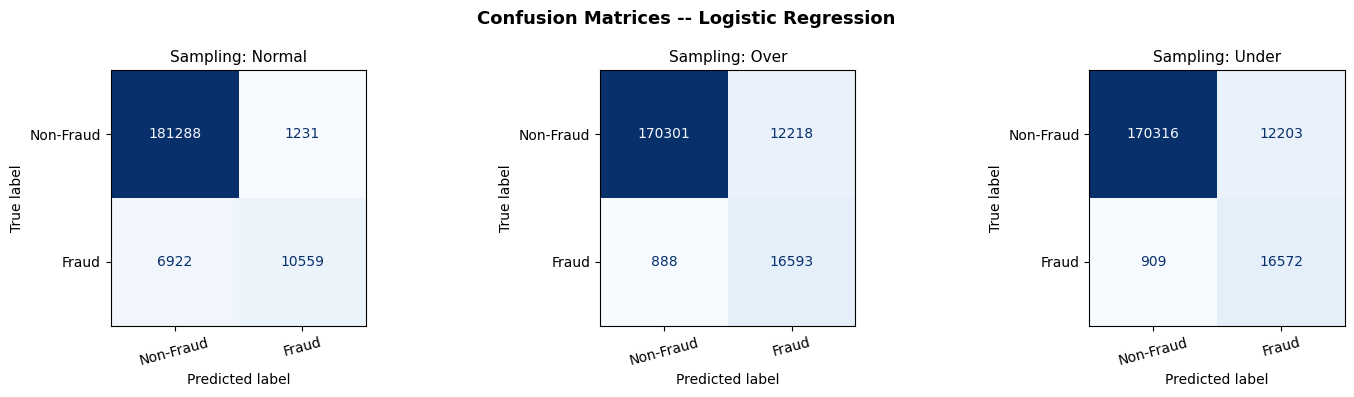

  Saved: charts/confusion_Logistic_Regression.png


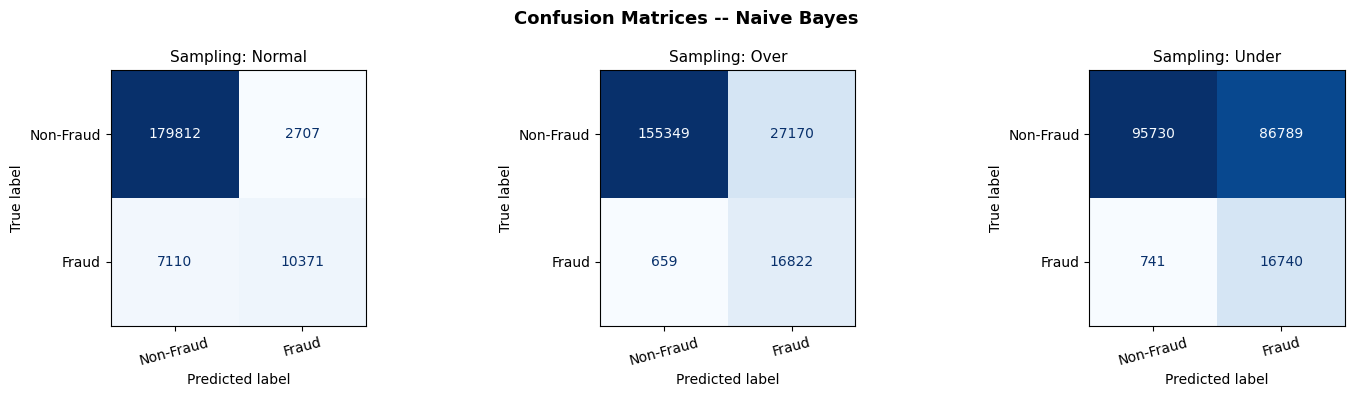

  Saved: charts/confusion_Naive_Bayes.png


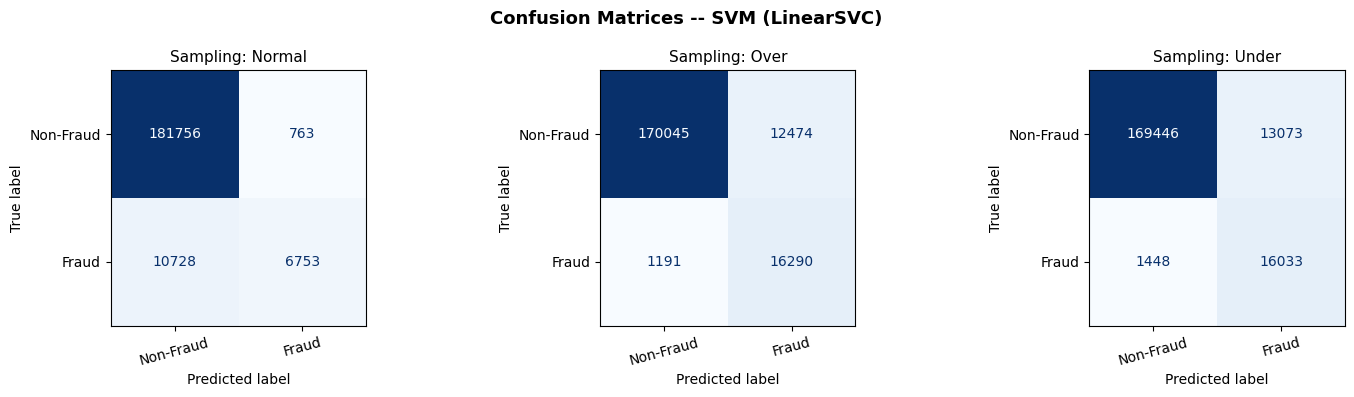

  Saved: charts/confusion_SVM_LinearSVC.png


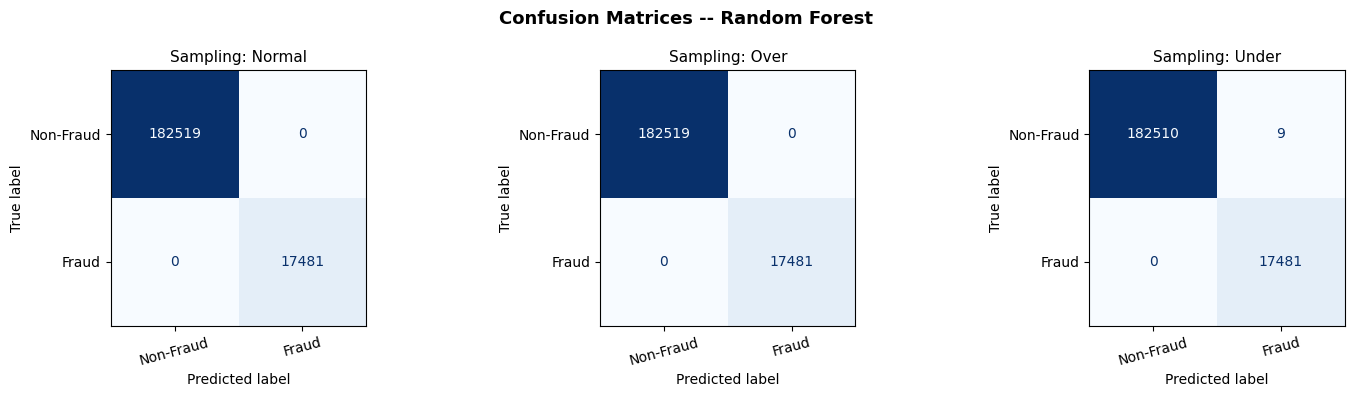

  Saved: charts/confusion_Random_Forest.png


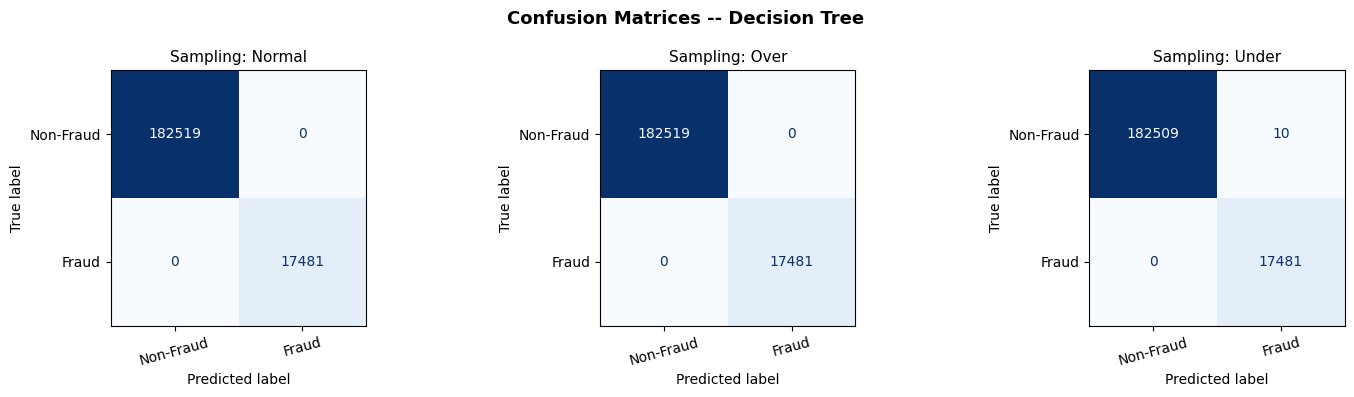

  Saved: charts/confusion_Decision_Tree.png


In [8]:
# Confusion matrices from the last experiment, one figure per model.
# Rows are the actual class and columns the predicted class, so the
# bottom-left cell is fraud that was missed.

print('Confusion Matrices (final experiment)')

for model_name in MODEL_NAMES:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Confusion Matrices -- {model_name}', fontsize=13, fontweight='bold')

    for ax, regime in zip(axes, REGIMES):
        cm = final_cms[model_name][regime]
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Non-Fraud', 'Fraud']
        )
        disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
        ax.set_title(f'Sampling: {regime}', fontsize=11)
        ax.tick_params(axis='x', labelrotation=15)

    plt.tight_layout()
    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '')
    out_path = os.path.join(CHART_DIR, f'confusion_{safe_name}.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: charts/{os.path.basename(out_path)}')

### Charts

Grouped bar charts with one group per model and one bar per sampling method (Normal / Over / Under). Error bars show ±1 standard deviation over the 10 experiments.

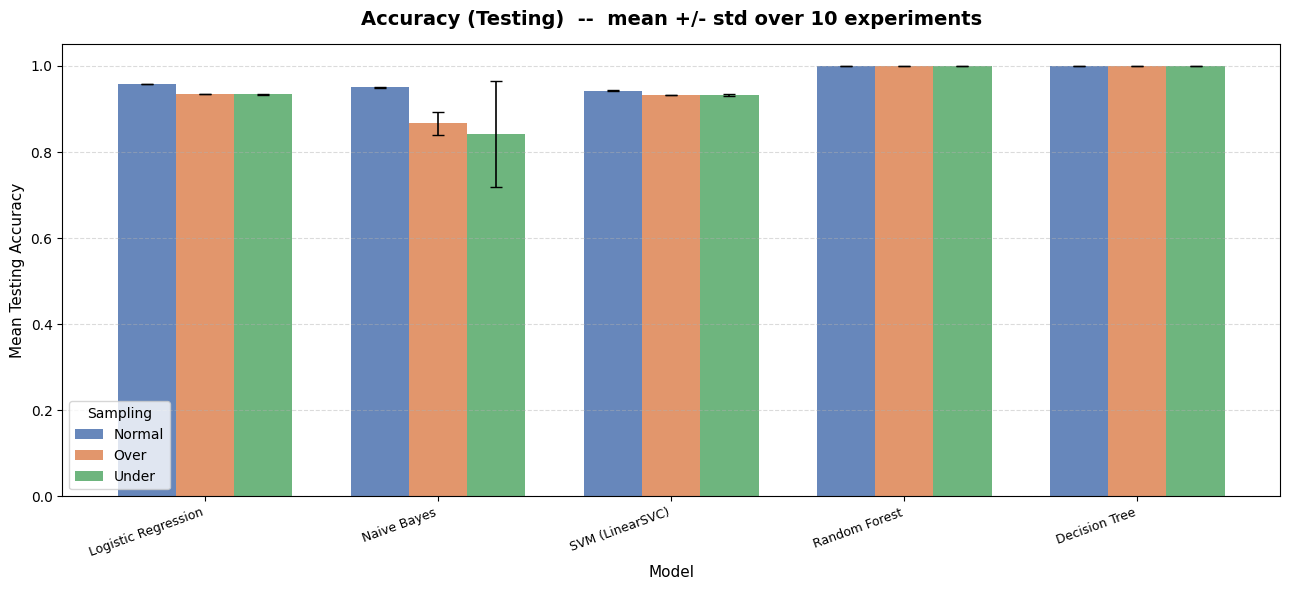

  Saved: charts/chart_accuracy.png


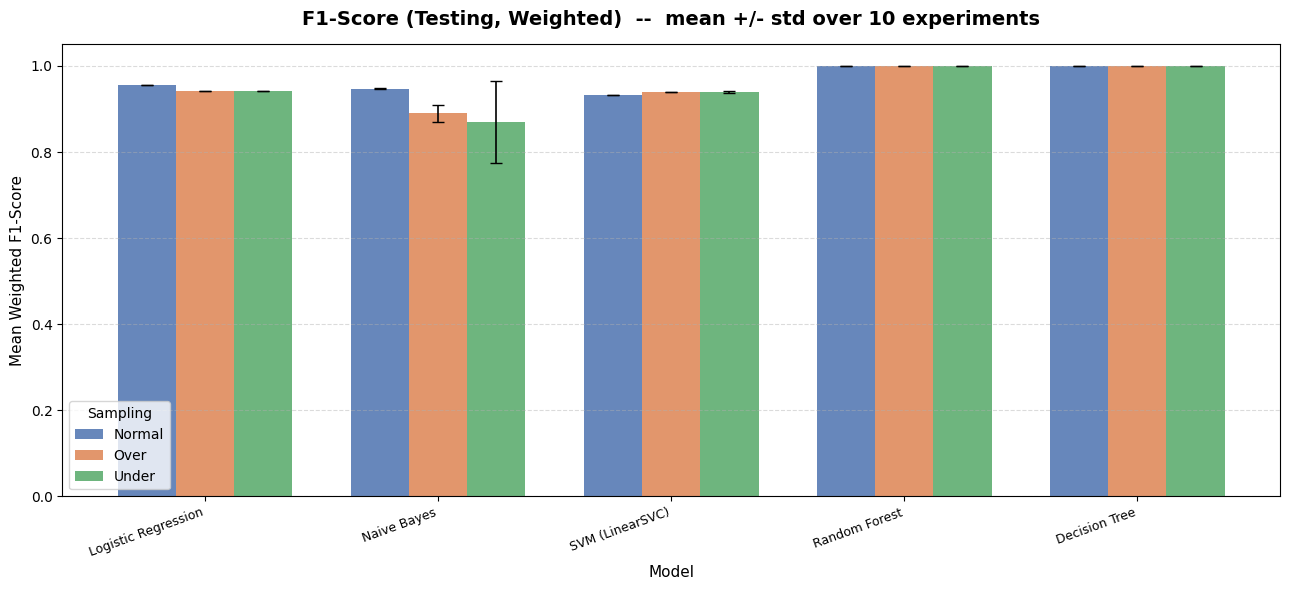

  Saved: charts/chart_f1.png


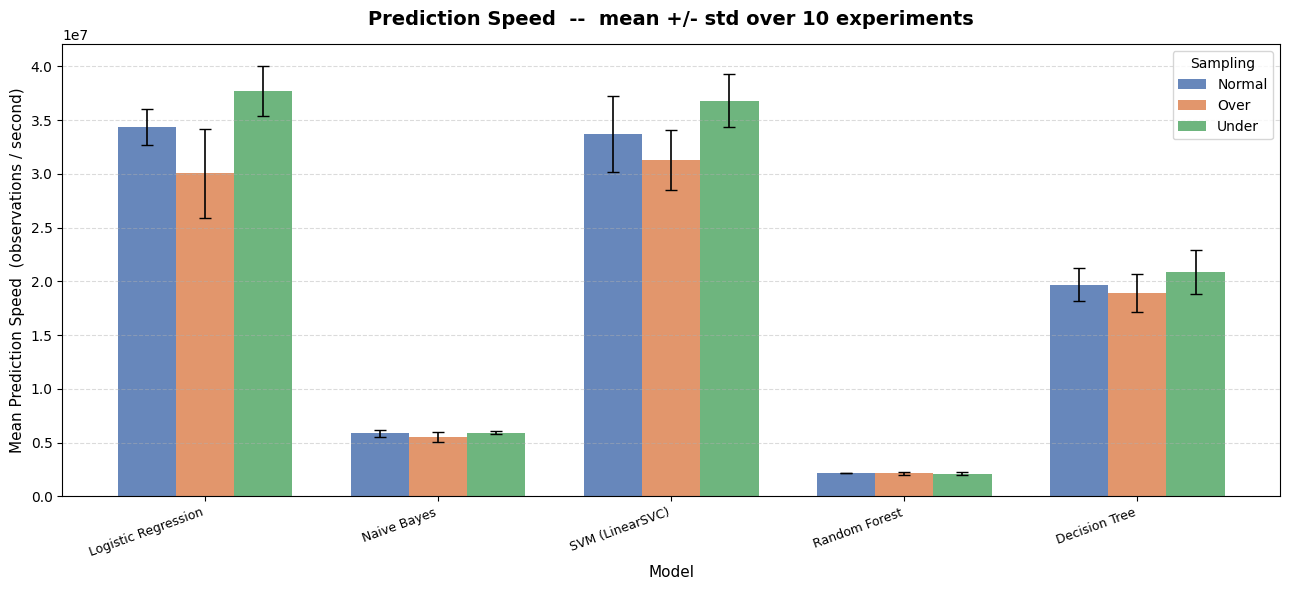

  Saved: charts/chart_pred_speed.png


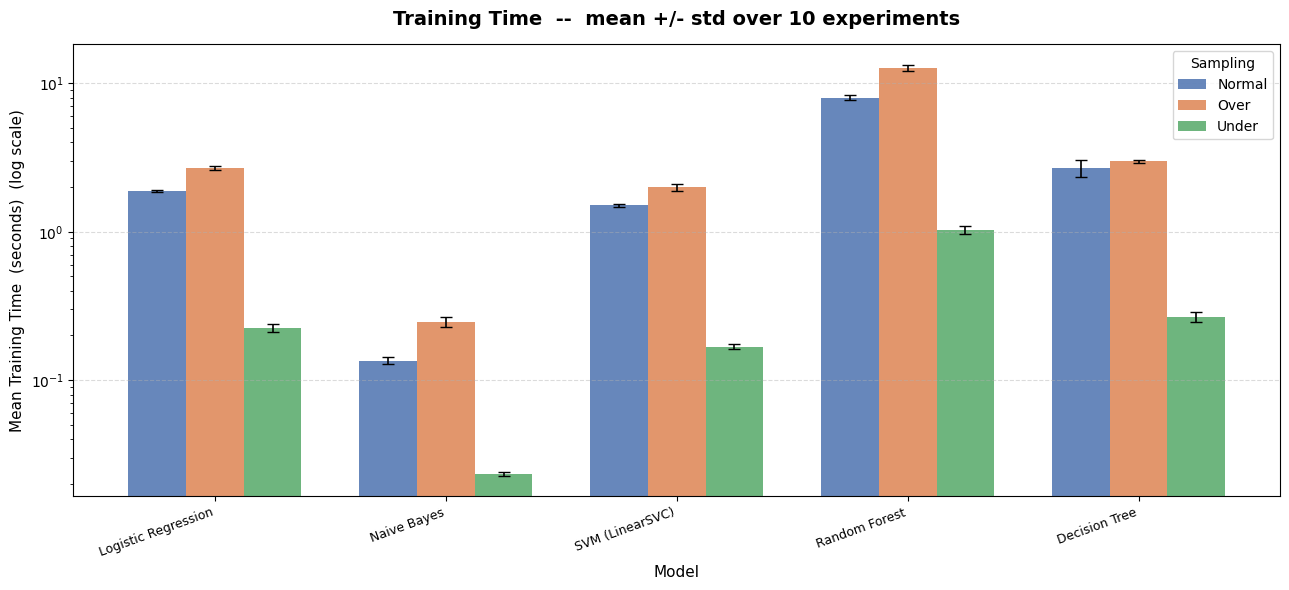

  Saved: charts/chart_train_time.png

All done. Charts saved in the charts folder.


In [9]:
# Grouped bar charts: one group per model, one bar per regime,
# error bars are +/- 1 std over the 10 experiments

REGIME_COLORS = {
    'Normal': '#4C72B0',
    'Over'  : '#DD8452',
    'Under' : '#55A868',
}

def plot_grouped_bar(metric_key, title, ylabel, filename, log_scale=False):
    """
    Display a grouped bar chart inline and save it as a PNG.

    Parameters
    ----------
    metric_key : str   Key into summary dict ('accuracy', 'f1', etc.)
    title      : str   Chart title
    ylabel     : str   Y-axis label
    filename   : str   Output PNG filename (saved in charts/)
    log_scale  : bool  If True, use log scale on y-axis (useful for train time
                       where RF can be orders of magnitude slower than Naive Bayes)
    """
    n_models  = len(MODEL_NAMES)
    x         = np.arange(n_models)
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(13, 6))

    for bar_idx, regime in enumerate(REGIMES):
        means = [summary[m][regime][metric_key][0] for m in MODEL_NAMES]
        stds  = [summary[m][regime][metric_key][1] for m in MODEL_NAMES]

        # shift each regime left/centre/right
        bar_offsets = x + (bar_idx - 1) * bar_width

        ax.bar(
            bar_offsets, means,
            width     = bar_width,
            label     = regime,
            color     = REGIME_COLORS[regime],
            yerr      = stds,
            capsize   = 4,
            alpha     = 0.85,
            error_kw  = {'linewidth': 1.2},
        )

    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Model', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right', fontsize=9)
    ax.legend(title='Sampling', fontsize=10, title_fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.45)

    if log_scale:
        ax.set_yscale('log')
        ax.set_ylabel(ylabel + '  (log scale)', fontsize=11)

    plt.tight_layout()
    out_path = os.path.join(CHART_DIR, filename)
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: charts/{os.path.basename(out_path)}')


plot_grouped_bar(
    'accuracy',
    'Accuracy (Testing)  --  mean +/- std over 10 experiments',
    'Mean Testing Accuracy',
    'chart_accuracy.png',
)
plot_grouped_bar(
    'f1',
    'F1-Score (Testing, Weighted)  --  mean +/- std over 10 experiments',
    'Mean Weighted F1-Score',
    'chart_f1.png',
)
plot_grouped_bar(
    'pred_speed',
    'Prediction Speed  --  mean +/- std over 10 experiments',
    'Mean Prediction Speed  (observations / second)',
    'chart_pred_speed.png',
)
plot_grouped_bar(
    'train_time',
    'Training Time  --  mean +/- std over 10 experiments',
    'Mean Training Time  (seconds)',
    'chart_train_time.png',
    log_scale=True,   # RF is much slower than the rest
)

print('\nAll done. Charts saved in the charts folder.')